In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')
from collections import Counter
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from torch.optim import AdamW

In [2]:
data_train = pd.read_csv('/content/twitter_training.csv')
data_test = pd.read_csv('/content/twitter_validation.csv')

In [3]:
df_train = data_train
df_test = data_test

In [4]:
df_train

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
...,...,...,...,...
74676,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74677,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,Positive,Just realized between the windows partition of...


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [17]:
df_train.columns = ['tweet_id', 'entity', 'sentiment', 'text']
df_test.columns = ['tweet_id', 'entity', 'sentiment', 'text']

In [18]:
display(df_train.head())
display(df_test.head())

,tweet_id,entity,sentiment,text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


,tweet_id,entity,sentiment,text
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...


In [19]:
df_train['sentiment'].value_counts()

,count
sentiment,
Negative,22542
Positive,20831
Neutral,18318
Irrelevant,12990


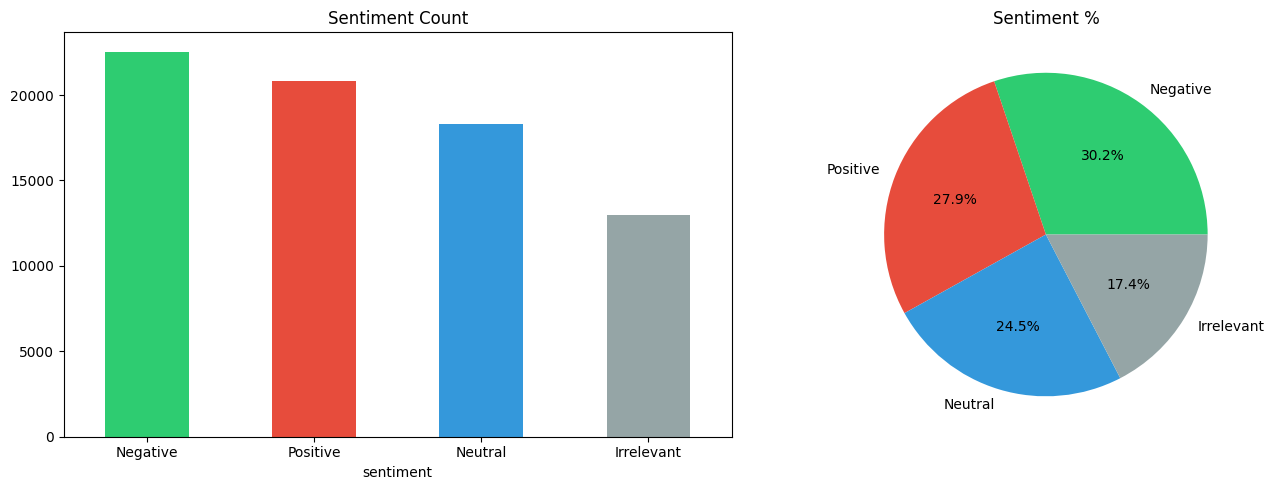

In [20]:
# EDA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_train['sentiment'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#2ecc71', '#e74c3c', '#3498db', '#95a5a6'])
axes[0].set_title('Sentiment Count')
axes[0].tick_params(axis='x', rotation=0)

df_train['sentiment'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c', '#3498db', '#95a5a6'])
axes[1].set_title('Sentiment %')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [21]:
df = df_train

In [22]:
# Preprocessing
df = df.dropna(subset=['text', 'sentiment'])
df = df[df['sentiment'] != 'Irrelevant']
print(f"\nAfter cleaning: {df.shape}")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

df = df[df['clean_text'].str.strip() != '']

le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])
print("Label mapping:", dict(zip(le.classes_, range(len(le.classes_)))))

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label'])

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

def plot_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(title, fontsize=14)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


After cleaning: (61120, 4)
Label mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}
Train: 48,650  |  Test: 12,163


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

...

Ep 3/4 | Train Loss 0.1606 | Train Acc 0.9422 || Val Loss 0.2929 | Val Acc 0.9116 | Val F1 0.9115


Ep 4/4 | Train Loss 0.0955 | Train Acc 0.9640 || Val Loss 0.3108 | Val Acc 0.9153 | Val F1 0.9153


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


BERT model saved to ./bert_sentiment



Final BERT Accuracy: 91.53% | Final F1: 0.9153
              precision    recall  f1-score   support

    Negative       0.93      0.93      0.93      4451
     Neutral       0.90      0.90      0.90      3596
    Positive       0.92      0.92      0.92      4116

    accuracy                           0.92     12163
   macro avg       0.91      0.91      0.91     12163
weighted avg       0.92      0.92      0.92     12163



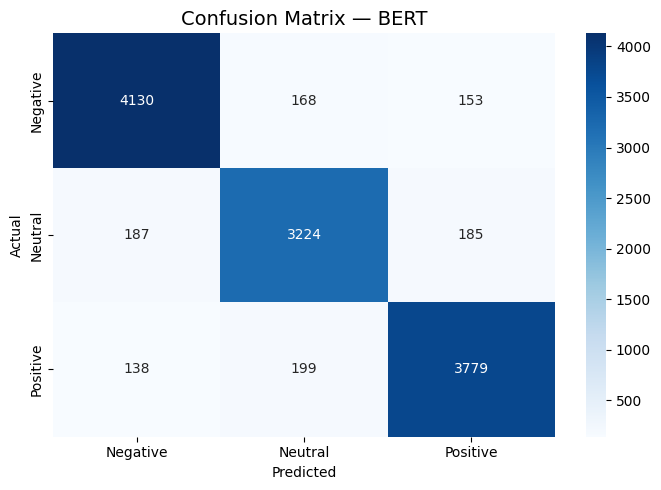

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. FIX: Define the Device and Number of Classes
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = len(le.classes_) # Dynamically pulls 3 classes from your LabelEncoder

# 2. OPTIMIZATION: Increased MAX_LEN to 128 for better context
BERT_MODEL   = 'bert-base-uncased'
BERT_MAX_LEN = 128
BERT_BATCH   = 32
BERT_EPOCHS  = 4
BERT_LR      = 2e-5

# 3. OPTIMIZATION: Removed .head() so you train on the full 60k dataset
Xb_train = X_train.reset_index(drop=True)
yb_train = y_train.reset_index(drop=True)
Xb_test  = X_test.reset_index(drop=True)
yb_test  = y_test.reset_index(drop=True)

tokenizer = BertTokenizer.from_pretrained(BERT_MODEL)

class BertDataset(Dataset):
    def __init__(self, texts, labels):
        # Convert pandas series to lists for faster indexing
        self.texts  = texts.tolist() if hasattr(texts, 'tolist') else texts
        self.labels = labels.tolist() if hasattr(labels, 'tolist') else labels

    def __len__(self): return len(self.texts)

    def __getitem__(self, i):
        enc = tokenizer(self.texts[i], max_length=BERT_MAX_LEN,
                        padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[i], dtype=torch.long)
        }

# OPTIMIZATION: Added num_workers=2 to speed up data loading on the CPU
bert_train_loader = DataLoader(BertDataset(Xb_train, yb_train),
                                batch_size=BERT_BATCH, shuffle=True,
                                pin_memory=torch.cuda.is_available(), num_workers=2)
bert_test_loader  = DataLoader(BertDataset(Xb_test, yb_test),
                                batch_size=BERT_BATCH,
                                pin_memory=torch.cuda.is_available(), num_workers=2)

bert_model  = BertForSequenceClassification.from_pretrained(
                  BERT_MODEL, num_labels=NUM_CLASSES).to(DEVICE)

optimizer_b  = AdamW(bert_model.parameters(), lr=BERT_LR, eps=1e-8)
total_steps  = len(bert_train_loader) * BERT_EPOCHS
scheduler    = get_linear_schedule_with_warmup(optimizer_b,
                   num_warmup_steps=total_steps // 10,
                   num_training_steps=total_steps)

def bert_train_epoch(model, loader):
    model.train()
    total_loss, total_correct = 0, 0
    for batch in tqdm(loader, desc="Training", leave=False):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        labs = batch['label'].to(DEVICE)

        optimizer_b.zero_grad()
        out  = model(ids, attention_mask=mask, labels=labs)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer_b.step()
        scheduler.step()

        total_loss    += out.loss.item()
        total_correct += (out.logits.argmax(1) == labs).sum().item()

    return total_loss / len(loader), total_correct / len(loader.dataset)

# FIX: Added labels to model() call so we can calculate Validation Loss
# FIX: Added F1-Score calculation
def bert_eval(model, loader):
    model.eval()
    total_loss, total_correct = 0, 0
    preds_all, labels_all = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            labs = batch['label'].to(DEVICE)

            out  = model(ids, attention_mask=mask, labels=labs)
            total_loss += out.loss.item()

            p    = out.logits.argmax(1)
            total_correct += (p == labs).sum().item()

            preds_all.extend(p.cpu().numpy())
            labels_all.extend(labs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc  = total_correct / len(loader.dataset)
    val_f1   = f1_score(labels_all, preds_all, average='weighted')

    return val_loss, val_acc, val_f1, preds_all

# FIX: Created a dictionary to store metrics for plotting
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

print("Training BERT...\n")
for ep in range(1, BERT_EPOCHS + 1):
    tr_loss, tr_acc = bert_train_epoch(bert_model, bert_train_loader)
    vl_loss, vl_acc, vl_f1, _ = bert_eval(bert_model, bert_test_loader)

    # Store metrics
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
    history['val_f1'].append(vl_f1)

    print(f"Ep {ep}/{BERT_EPOCHS} | Train Loss {tr_loss:.4f} | Train Acc {tr_acc:.4f} || Val Loss {vl_loss:.4f} | Val Acc {vl_acc:.4f} | Val F1 {vl_f1:.4f}")

bert_model.save_pretrained('./bert_sentiment')
tokenizer.save_pretrained('./bert_sentiment')
print("\nBERT model saved to ./bert_sentiment")

# Final Evaluation & Reports
_, acc_bert, f1_bert, y_pred_bert = bert_eval(bert_model, bert_test_loader)
print(f"\nFinal BERT Accuracy: {acc_bert*100:.2f}% | Final F1: {f1_bert:.4f}")
print(classification_report(list(yb_test), y_pred_bert, target_names=le.classes_))

# Re-using your confusion matrix function
plot_confusion_matrix(list(yb_test), y_pred_bert, le.classes_, 'Confusion Matrix — BERT')

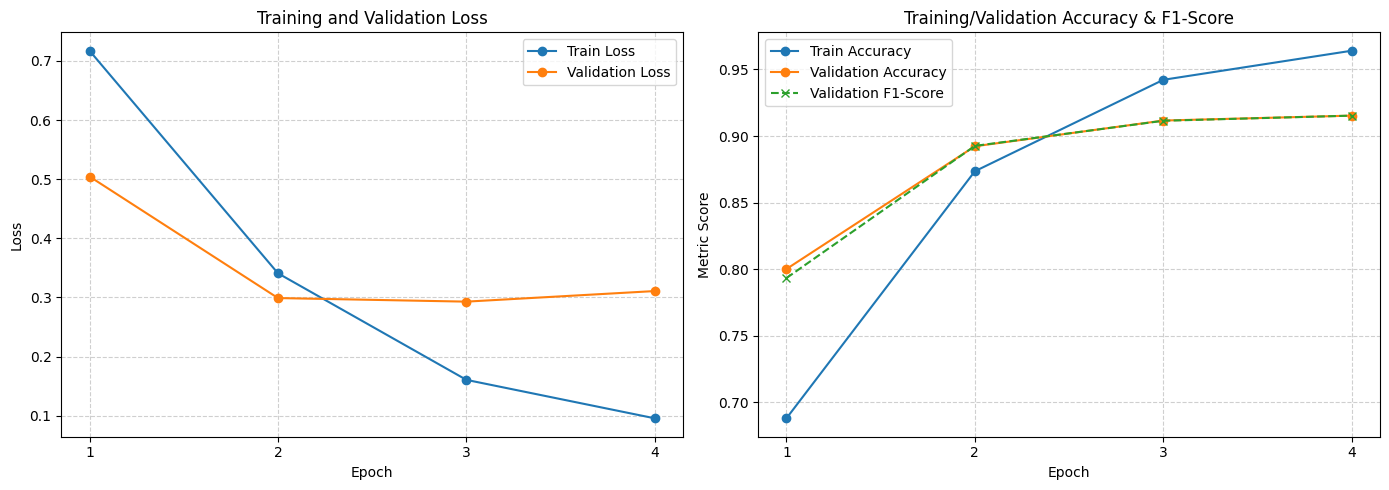

In [24]:
# Plotting the Training History
epochs_range = range(1, BERT_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_xticks(epochs_range)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Accuracy & F1
axes[1].plot(epochs_range, history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='o')
axes[1].plot(epochs_range, history['val_f1'], label='Validation F1-Score', marker='x', linestyle='--')
axes[1].set_title('Training/Validation Accuracy & F1-Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Metric Score')
axes[1].set_xticks(epochs_range)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [25]:
import pandas as pd
import torch
import re
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.metrics import classification_report, accuracy_score
from tqdm import tqdm

# 1. Setup Device and Constants
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_PATH = './bert_sentiment'
BERT_MAX_LEN = 128
BERT_BATCH = 32

# Recreate the label mapping from training
LABEL_MAP = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
TARGET_NAMES = ['Negative', 'Neutral', 'Positive']

# 2. Load Model and Tokenizer
print("Loading model and tokenizer...")
tokenizer = BertTokenizer.from_pretrained(MODEL_PATH)
model = BertForSequenceClassification.from_pretrained(MODEL_PATH).to(DEVICE)
model.eval()

# 3. Data Cleaning Function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 4. Dataset Class
class BertEvalDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts.tolist()
        self.labels = labels.tolist()

    def __len__(self): return len(self.texts)

    def __getitem__(self, i):
        enc = tokenizer(self.texts[i], max_length=BERT_MAX_LEN,
                        padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[i], dtype=torch.long)
        }

# 5. Load and Prepare Validation Data
print("Loading and preprocessing validation data...")
df_val = pd.read_csv('/content/twitter_validation.csv', names=['tweet_id', 'entity', 'sentiment', 'text'])
df_val = df_val.dropna(subset=['text', 'sentiment'])
df_val = df_val[df_val['sentiment'] != 'Irrelevant'] # Drop irrelevant class
df_val['clean_text'] = df_val['text'].apply(clean_text)
df_val = df_val[df_val['clean_text'].str.strip() != '']
df_val['label'] = df_val['sentiment'].map(LABEL_MAP)

# Create DataLoader
val_loader = DataLoader(
    BertEvalDataset(df_val['clean_text'], df_val['label']),
    batch_size=BERT_BATCH,
    pin_memory=torch.cuda.is_available(),
    num_workers=2
)

# 6. Evaluation Loop
print("Evaluating...")
preds_all, labels_all = [], []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Testing"):
        ids = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)

        out = model(ids, attention_mask=mask)
        p = out.logits.argmax(1)

        preds_all.extend(p.cpu().numpy())
        labels_all.extend(batch['label'].numpy())

# 7. Print Results
acc = accuracy_score(labels_all, preds_all)
print(f"\nValidation Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(labels_all, preds_all, target_names=TARGET_NAMES))

Loading model and tokenizer...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading and preprocessing validation data...
Evaluating...


Testing: 100%|██████████| 26/26 [00:06<00:00,  4.24it/s]


Validation Accuracy: 97.22%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.97      0.98       266
     Neutral       0.98      0.97      0.97       285
    Positive       0.96      0.98      0.97       277

    accuracy                           0.97       828
   macro avg       0.97      0.97      0.97       828
weighted avg       0.97      0.97      0.97       828



In [26]:
import torch
import re
from transformers import BertTokenizer, BertForSequenceClassification

# 1. Setup Device and Constants
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_PATH = './bert_sentiment'
BERT_MAX_LEN = 128

# Reverse mapping to turn numerical predictions back into text
REVERSE_LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

# 2. Load Model and Tokenizer
print("Loading model and tokenizer...")
tokenizer = BertTokenizer.from_pretrained(MODEL_PATH)
model = BertForSequenceClassification.from_pretrained(MODEL_PATH).to(DEVICE)
model.eval()

# 3. Data Cleaning Function (Must match training!)
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 4. Prediction Function
def predict_sentiment(tweet_text):
    # Clean text
    cleaned_text = clean_text(tweet_text)

    # Tokenize
    inputs = tokenizer(cleaned_text, max_length=BERT_MAX_LEN,
                       padding='max_length', truncation=True, return_tensors='pt')

    # Move to device
    ids = inputs['input_ids'].to(DEVICE)
    mask = inputs['attention_mask'].to(DEVICE)

    # Predict
    with torch.no_grad():
        outputs = model(ids, attention_mask=mask)
        predicted_class_id = outputs.logits.argmax(dim=1).item()

    return REVERSE_LABEL_MAP[predicted_class_id]

# 5. Test it out!
if __name__ == "__main__":
    custom_tweets = [
        "I absolutely love the new features in the latest update! Great job.",
        "My game keeps crashing every 5 minutes. This is completely unplayable.",
        "I bought a coffee today, the weather is nice.",
        "@Microsoft Why do I pay for WORD when it functions so poorly? 🙄"
    ]

    print("\n--- Predictions ---")
    for tweet in custom_tweets:
        sentiment = predict_sentiment(tweet)
        print(f"Tweet: '{tweet}'")
        print(f"Predicted Sentiment: {sentiment}\n")

Loading model and tokenizer...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


--- Predictions ---
Tweet: 'I absolutely love the new features in the latest update! Great job.'
Predicted Sentiment: Positive

Tweet: 'My game keeps crashing every 5 minutes. This is completely unplayable.'
Predicted Sentiment: Negative

Tweet: 'I bought a coffee today, the weather is nice.'
Predicted Sentiment: Positive

Tweet: '@Microsoft Why do I pay for WORD when it functions so poorly? 🙄'
Predicted Sentiment: Negative



In [27]:
sample_tweet = "This movie was fantastic! I loved every minute of it."
predicted_sentiment = predict_sentiment(sample_tweet)
print(f"Sample Tweet: '{sample_tweet}'")
print(f"Predicted Sentiment: {predicted_sentiment}")

Sample Tweet: 'This movie was fantastic! I loved every minute of it.'
Predicted Sentiment: Positive


In [28]:
import shutil
from google.colab import files

# Name of the folder to download
folder_to_download = 'bert_sentiment'

# Create a zip archive of the folder
zip_filename = f'{folder_to_download}.zip'
shutil.make_archive(folder_to_download, 'zip', folder_to_download)

# Download the zip file
files.download(zip_filename)

print(f"'{zip_filename}' has been prepared for download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'bert_sentiment.zip' has been prepared for download.
